In [201]:
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.optimize import brentq
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import plotly.graph_objects as go
from plotly.subplots import make_subplots


from datetime import datetime
from pandas.tseries.offsets import BDay
import pandas_datareader.data as pdr

In [202]:
transaction_data = pd.read_excel("./Transaction Data.xlsx")
# print(transaction_data.tail())

In [203]:
all_tickers = list(transaction_data['Ticker'].unique())

#Remove delisted stock
blackList = []

filt_tickers = [tick for tick in all_tickers if tick not in blackList]
print("You traded {} different assets".format(len(all_tickers)))

You traded 12 different assets


In [204]:
filt_tickers

['FANG',
 'ASTS',
 'BTI',
 'NVDA',
 'PLTR',
 'LYG',
 'BTC-USD',
 'SOL-USD',
 'KO',
 'SUI20947-USD',
 'GOOGL',
 'SPCX']

In [205]:
final_filtered = transaction_data[~transaction_data.Ticker.isin(blackList)]

# PRICE HISTORY

In [206]:
start_date = '2021-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

raw = yf.download(
    filt_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

price_data = (
    raw.swaplevel(0, 1, axis=1)   # (Ticker, Field)
       .sort_index(axis=1)
       .stack(level=0)            # Ticker → rows
       .rename_axis(["Date", "Ticker"])
       .reset_index()
       .set_index(["Ticker", "Date"])
       .sort_index()
)

In [207]:
tx = transaction_data.copy()
tx["Date"] = pd.to_datetime(tx["Date"])
tx["Type"] = tx["Type"].str.upper()

# Signed shares & cash flow
tx["Signed_shares"] = tx["Shares"].where(
    tx["Type"] == "BUY", -tx["Shares"])

tx["cash_flow"] = tx["Total Cost/Credit ($)"].where(
    tx["Type"] == "SELL", -tx["Total Cost/Credit ($)"])

tx.tail(10)

,Date,Ticker,Asset,Type,Shares,Cost/Share ($),Commn,Total Cost/Credit ($),Signed_shares,cash_flow
75,2026-07-08,GOOGL,Equity,BUY,0.508391,365.29,0.47,186.179999,0.508391,-186.179999
76,2026-07-08,BTI,Equity,BUY,5.041766,61.55,0.00,310.320677,5.041766,-310.320677
77,2026-07-08,LYG,Equity,BUY,20.066945,5.99,0.31,120.511000,20.066945,-120.511000
78,2026-07-08,NVDA,Equity,BUY,1.899893,195.49,0.93,372.339999,1.899893,-372.339999
79,2026-07-08,PLTR,Equity,BUY,1.434719,129.44,0.47,186.179999,1.434719,-186.179999
80,2026-07-08,ASTS,Equity,BUY,5.015935,74.05,0.93,372.359999,5.015935,-372.359999
81,2026-07-14,NVDA,Equity,SELL,1.254458,208.27,0.67,260.595914,-1.254458,260.595914
82,2026-07-14,FANG,Equity,SELL,1.085530,193.56,0.54,209.575107,-1.085530,209.575107
83,2026-07-14,KO,Equity,SELL,6.813016,84.26,1.45,572.614733,-6.813016,572.614733
84,2026-09-09,KO,Equity,BUY,4.823630,88.11,0.00,425.010000,4.823630,-425.010000


In [208]:
close_prices = price_data["Close"]
close_prices.index = close_prices.index.set_levels(
    pd.to_datetime(close_prices.index.levels[1]),
    level=1)

close_prices

Ticker        Date      
ASTS          2021-01-04    12.950000
              2021-01-05    13.090000
              2021-01-06    12.940000
              2021-01-07    12.780000
              2021-01-08    12.690000
                              ...    
SUI20947-USD  2026-09-27     1.268229
              2026-09-28     1.166706
              2026-09-29     1.150854
              2026-09-30     1.162911
              2026-10-01     1.175595
Name: Close, Length: 17069, dtype: float64

# MONTHLY BUYING


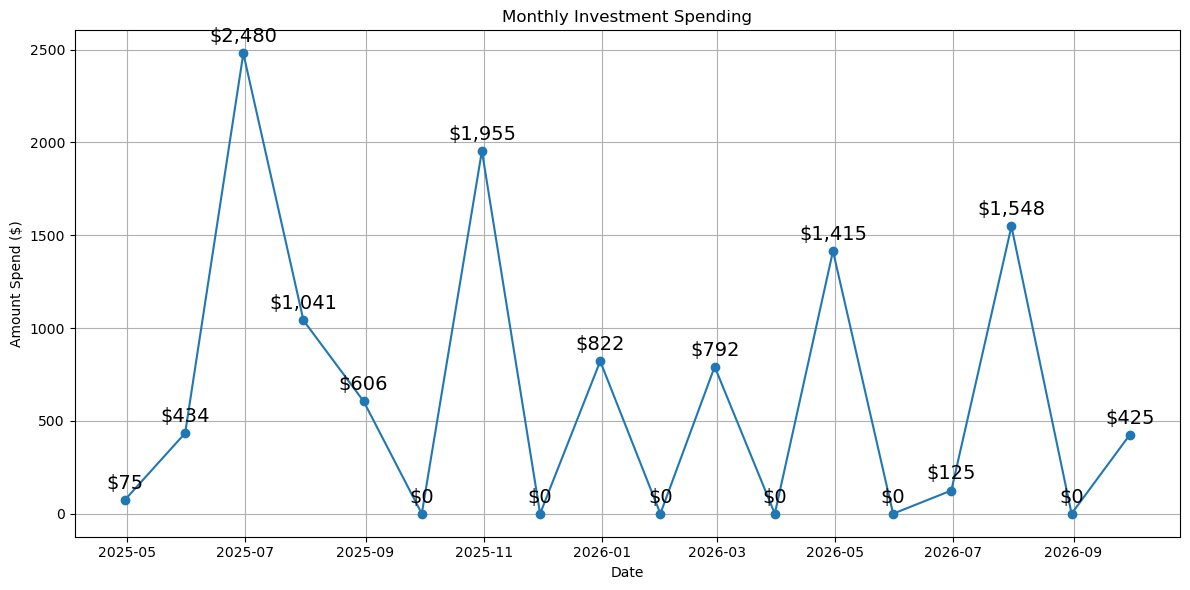

In [209]:
# Keep only Buy transactions 
buy_tx = tx[tx["Type"] == "BUY"].copy()

# Convert to monthy spending
monthly_spending = (buy_tx.set_index("Date").resample("M")["Total Cost/Credit ($)"].sum())

# Plot monthly spending
plt.figure(figsize=(12,6))
plt.plot(
    monthly_spending.index, 
    monthly_spending.values,
    marker = "o"
)
plt.title("Monthly Investment Spending")
plt.xlabel("Date")
plt.ylabel("Amount Spend ($)")
plt.grid(True)

# Add value labels
for x, y in zip(monthly_spending.index, monthly_spending.values):
    plt.annotate(
        f"${y:,.0f}",      # format number
        (x, y),            # point location
        textcoords="offset points",
        xytext=(0, 8),     # vertical offset
        ha="center",
        fontsize= 14
    )


plt.tight_layout()
plt.show()

# NET MONTHLY CF

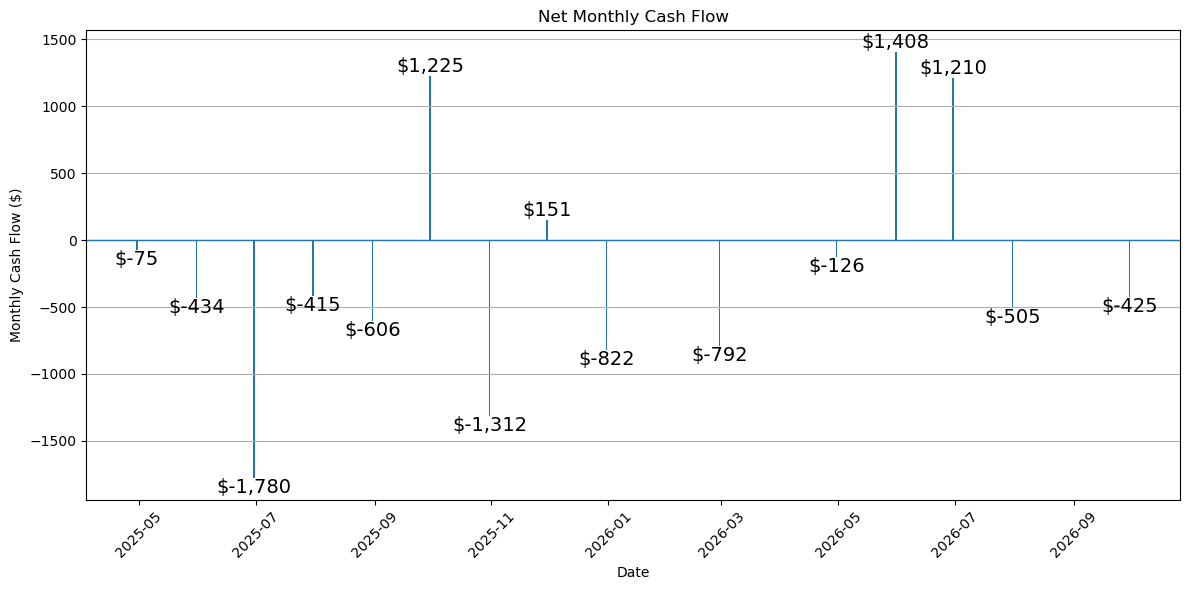

In [210]:
# Convert to Monthy Cash Flow
monthly_net_cf = (tx.set_index("Date").resample("M")["cash_flow"].sum())

# Plot
plt.figure(figsize=(12,6))

plt.bar(
    monthly_net_cf.index,
    monthly_net_cf.values
)

plt.axhline(0, linewidth=1) # Zero line
plt.title("Net Monthly Cash Flow")
plt.xlabel("Date")
plt.ylabel("Monthly Cash Flow ($)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")

# Value Label
for x, y in zip(monthly_net_cf.index, monthly_net_cf.values):
    if y != 0:
        plt.text(
            x,
            y,
            f"${y:,.0f}",
            ha = "center",
            va = "bottom" if y > 0 else "top",
            fontsize = 14
        )
        
plt.tight_layout()
plt.show()

# PORTFOLIO VALUE

In [211]:
### Already have transaction data tx above:
### Build daily holdings per stock

# First transaction date
start_portfolio_date = tx["Date"].min()
prices = close_prices.unstack("Ticker")
prices = prices.loc[prices.index >= start_portfolio_date]

# Forward-fill missing prices (market-closed days)
prices = prices.ffill().fillna(0)

# Aggregate trades by day and ticker:
daily_trades = (
    tx.groupby(["Date", "Ticker"])["Signed_shares"]
    .sum()
    .unstack("Ticker")
    .fillna(0)
)

# Reindex to daily frequency ad forward-fill holdings
daily_trades = daily_trades.reindex(
    prices.index,
    fill_value=0
)

daily_holdings = daily_trades.cumsum()

### Some issue to remember:
# NaNs are expected due to sparse trades and incomplete price histories.
# - No trade on a date ⇒ 0 shares traded (fill NaNs with 0 before cumsum)
# - Missing prices (IPOs, holidays) ⇒ forward-fill after first valid price
# - Assets only contribute to portfolio value once a position exists
# Explicit handling prevents artificial portfolio value drops.

In [212]:
### Porfolio Value
position_values = (
    prices
    .where(daily_holdings != 0, 0)   # only value when held
    .fillna(0)                       # no price → no valuation
    * daily_holdings
)

portfolio_value = position_values.sum(axis=1)

### Invested Capital
# Daily net cash flow
daily_cash_flow = (
    tx.groupby("Date")["cash_flow"]
    .sum()
    .reindex(portfolio_value.index, fill_value=0)
)

# Cumulative invested capital
invested_capital = (-daily_cash_flow).cumsum()

In [213]:
### Cost Basis Tracking
tx_sorted = tx.sort_values(["Ticker", "Date"]).copy()

records = []
realised_records = []

for ticker, df in tx_sorted.groupby("Ticker"):
    df = df.sort_values("Date")
    
    shares = 0.0
    cost = 0.0
    
    for _, row in df.iterrows():
        date = row["Date"]
        trade_type = row["Type"]
        qty = float(row["Shares"])
        total_cost = float(row["Total Cost/Credit ($)"])
        
        if trade_type == "BUY":
            shares += qty
            cost += total_cost
        
        elif trade_type == "SELL":
            if shares > 0:
                avg_cost = cost / shares
                cost_removed = avg_cost * qty
                
                # realised Pnl
                realised = total_cost - cost_removed
                
                realised_records.append({
                    "Date": date,
                    "Ticker": ticker,
                    "Realised_PnL": realised
                })
                
                shares -= qty
                cost -= cost_removed
        
        avg_cost = cost / shares if shares > 0 else 0
        
        records.append({
            "Date": date,
            "Ticker": ticker,
            "Shares": shares,
            "Cost_Basis": cost,
            "Avg_Cost": avg_cost
        })

cost_basis_df = pd.DataFrame(records)

# remove duplicate Date-Ticker rows (take end-of-day state)
cost_basis_df = (
    cost_basis_df
    .sort_values(["Ticker", "Date"])
    .groupby(["Date", "Ticker"], as_index=False)
    .last()
)

# Pivot to daily matrix
cost_basis_pivot = (
    cost_basis_df
    .set_index(["Date", "Ticker"])["Cost_Basis"]
    .unstack("Ticker")
)

# Align with price index
cost_basis_pivot = cost_basis_pivot.reindex(prices.index).ffill().fillna(0)

# Total portfolio cost basis
portfolio_cost_basis = cost_basis_pivot.sum(axis=1)

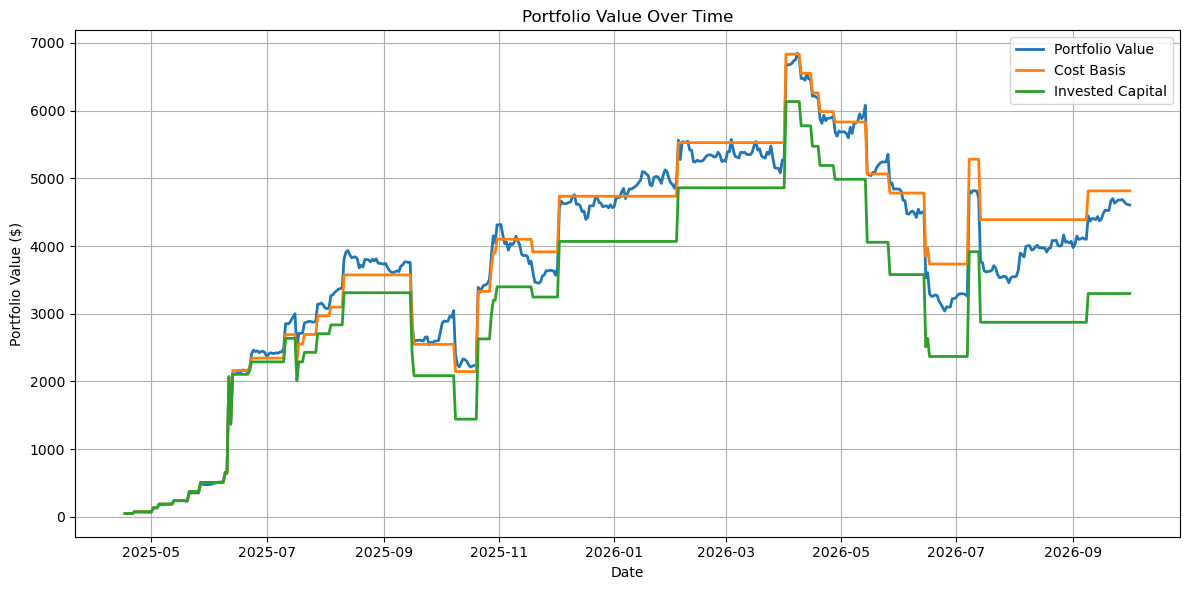

In [214]:


# Plot Portfolio Value + Invested Capital
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_value.index, 
    portfolio_value.values,
    label="Portfolio Value",
    linewidth=2
)

plt.plot(
    portfolio_cost_basis.index,
    portfolio_cost_basis.values,
    label="Cost Basis",
    linewidth=2
)

plt.plot(
    invested_capital.index,
    invested_capital.values,
    label="Invested Capital",
    linewidth=2
)

plt.title("Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Asset Distribution

In [215]:
# Take the lastest date:
latest_date = position_values.index.max()
latest_positions = position_values.loc[latest_date]

# Remove 0 value:
latest_positions = latest_positions[latest_positions > 0]

([<matplotlib.patches.Wedge at 0x1c38609de90>,
 [Text(-0.6882870395018462, 0.8580564965395835, 'Crypto'),
  Text(0.68828716000741, -0.85805639987645, 'Equity')],
 [Text(-0.3754292942737342, 0.4680308162943182, '21.5%'),
  Text(0.37542936000404176, -0.46803076356897266, '78.5%')])

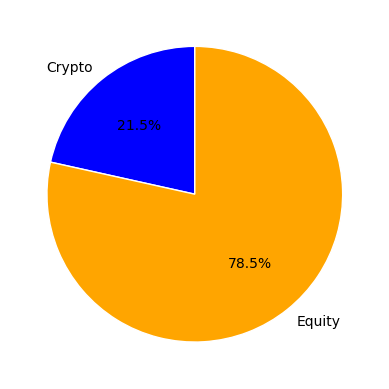

In [216]:
# Mapping asset type
ticker_asset_type = (
    tx[["Ticker", "Asset"]]
    .drop_duplicates()
    .set_index("Ticker")["Asset"]
)

# Aggregate latest portfolio value by asset type
asset_type_values = latest_positions.groupby(
    ticker_asset_type.loc[latest_positions.index]
).sum()

# Define colors by asset type (aligned with index order)
colors = [
    "orange" if asset == "Equity" else "blue"
    for asset in asset_type_values.index
]


# Distribution by Asset Type (Pie Chart - %)
plt.pie(
    asset_type_values,
    labels=asset_type_values.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white"}
)

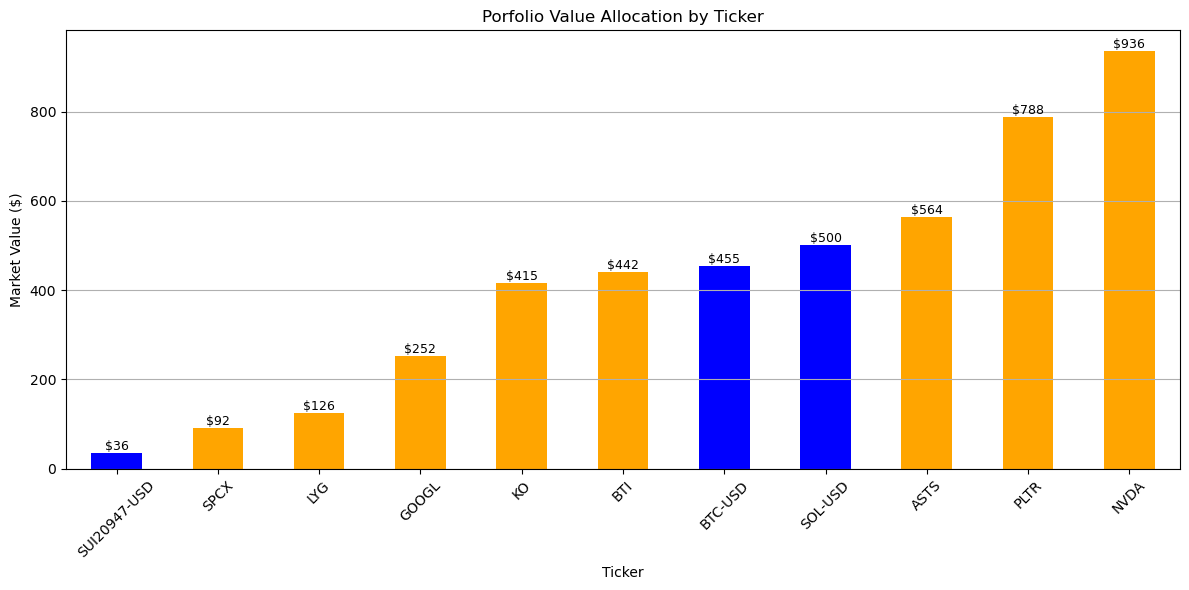

In [217]:
# Color ticker by asset
colors = [
    "orange" if ticker_asset_type[ticker] == "Equity" else "blue"
    for ticker in latest_positions.sort_values(ascending=True).index
]

# Distribution by ticker (Bar Chart - Value)
plt.figure(figsize=(12,6))
latest_positions.sort_values(ascending=True).plot(
    kind="bar",
    color=colors
)

plt.title("Porfolio Value Allocation by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Market Value ($)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")

sorted_val = latest_positions.sort_values(ascending=True)
for i, v in enumerate(sorted_val.values):
    plt.text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

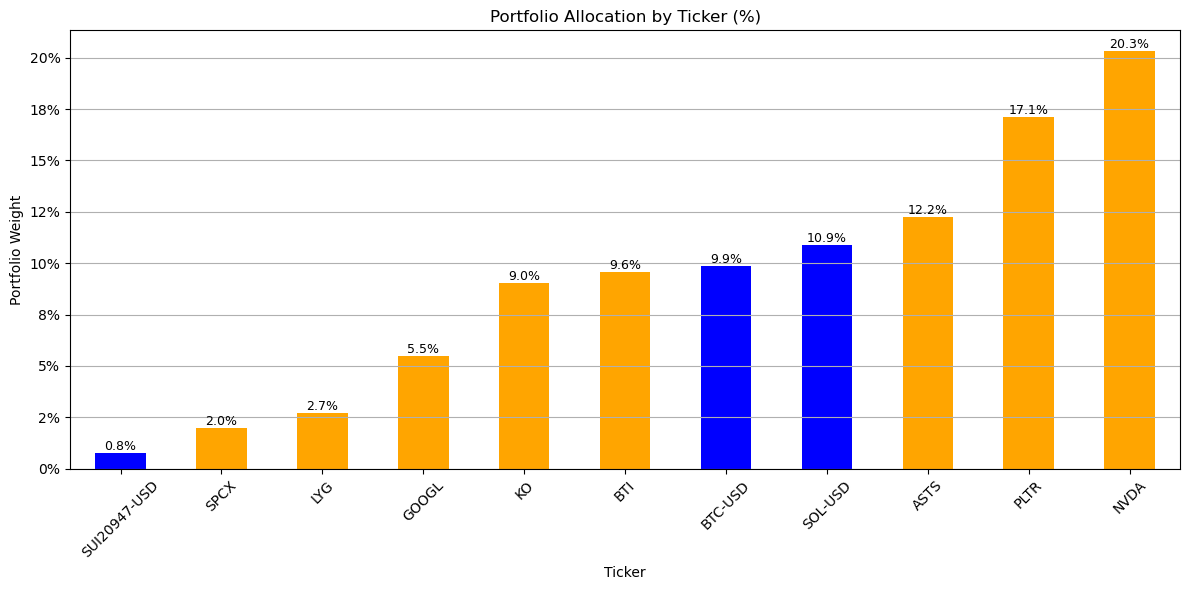

In [218]:
# Distribution by ticker (Bar Chart - %)
latest_positions_pct = latest_positions / latest_positions.sum()

# colors in the same sorted order as the bars
colors = [
    "orange" if ticker_asset_type[ticker] == "Equity" else "blue"
    for ticker in latest_positions_pct.sort_values(ascending=True).index
]

plt.figure(figsize=(12, 6))
latest_positions_pct.sort_values(ascending=True).plot(
    kind="bar",
    color=colors
)

plt.title("Portfolio Allocation by Ticker (%)")
plt.xlabel("Ticker")
plt.ylabel("Portfolio Weight")
plt.xticks(rotation=45)
plt.grid(True, axis="y")

# format y-axis as percentages
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

sorted_pct = latest_positions_pct.sort_values(ascending=True)
for i, v in enumerate(sorted_pct.values):
    plt.text(i, v, f"{v:.1%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\Owner\AppData\Local\Temp\ipykernel_2032\1847303673.py:4: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



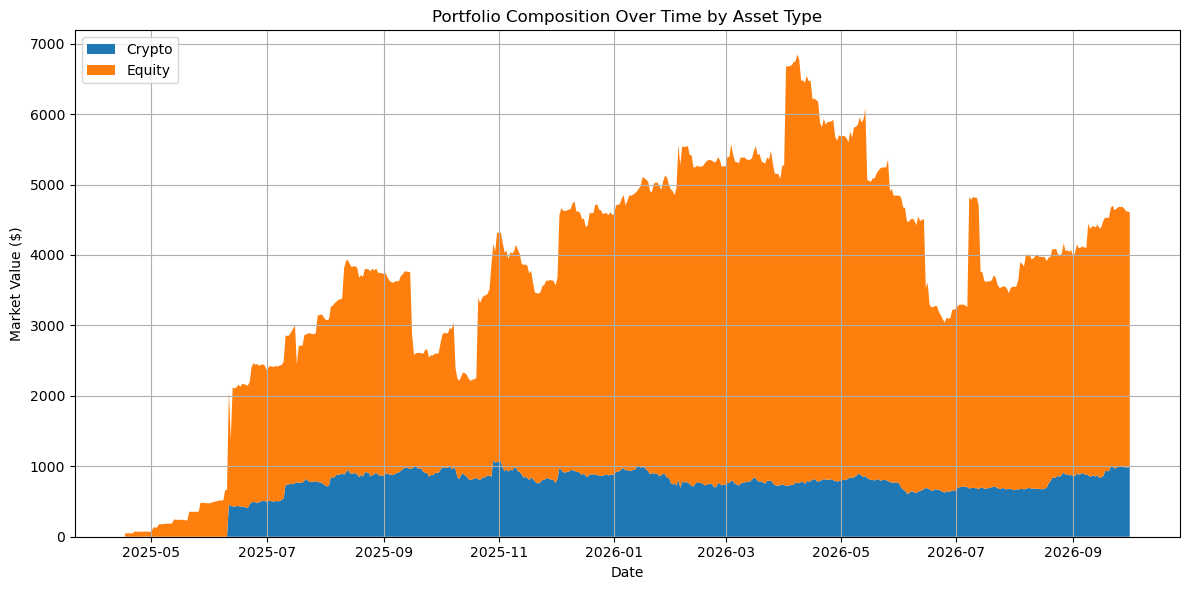

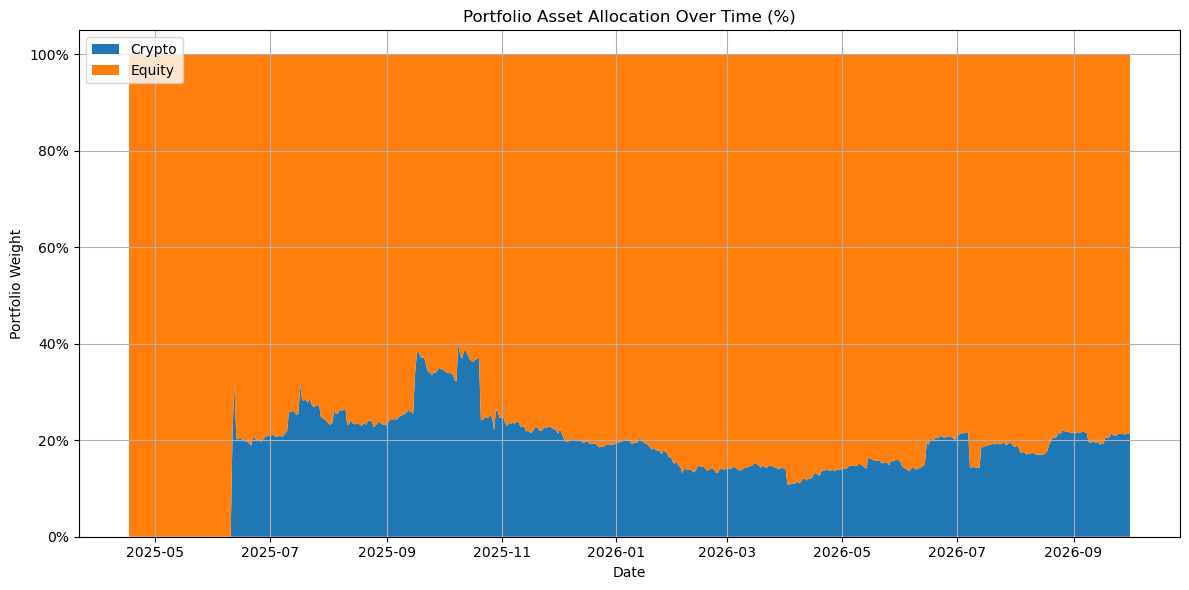

In [219]:
# Aggregate portfolio position values by Asset Type over time.
asset_type_over_time = (
    position_values
    .groupby(ticker_asset_type, axis=1)
    .sum()
)

# Plot portfolio composition over time using a stacked area chart.
plt.figure(figsize=(12, 6))
plt.stackplot(
    asset_type_over_time.index,
    asset_type_over_time.T.values,
    labels=asset_type_over_time.columns
)

plt.title("Portfolio Composition Over Time by Asset Type")
plt.xlabel("Date")
plt.ylabel("Market Value ($)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

#Plot Stacked % Over time

# Convert market values to portfolio weights (row-wise)
asset_type_pct = asset_type_over_time.div(
    asset_type_over_time.sum(axis=1),
    axis=0
)
asset_type_pct = asset_type_pct.fillna(0)

plt.figure(figsize=(12, 6))
plt.stackplot(
    asset_type_pct.index,
    asset_type_pct.T.values,
    labels=asset_type_pct.columns
)

plt.title("Portfolio Asset Allocation Over Time (%)")
plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.legend(loc="upper left")
plt.grid(True)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.tight_layout()
plt.show()


# Profit and Loss

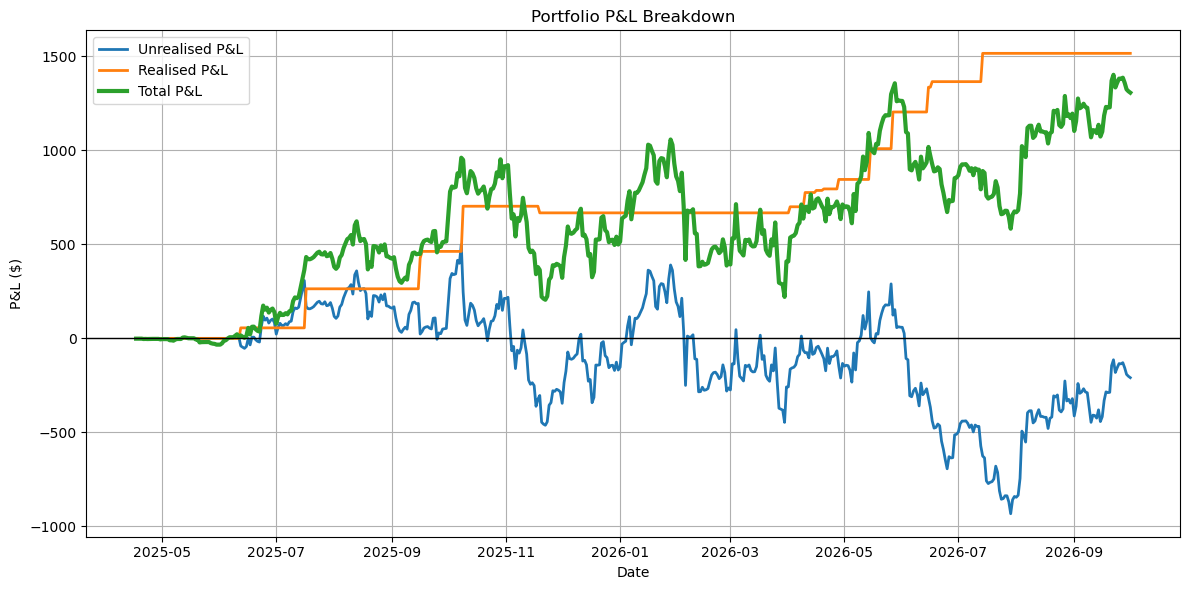

Current Unrealised G/L: $-209.14462216451102
Current Realised G/L: $1516.3210603623868
Total Current G/L: $1307.1764381978758
Cost Basis G/L: $-209.14462216451102


In [220]:
# Unrealised PnL
unrealised_pnl = portfolio_value - portfolio_cost_basis

# Realised PnL
realised_df = pd.DataFrame(realised_records)

realised_pnl = (
    realised_df
    .groupby("Date")["Realised_PnL"]
    .sum()
    .reindex(prices.index, fill_value=0)
    .cumsum()
)

# Total PnL
total_pnl= realised_pnl + unrealised_pnl

# Plot
plt.figure(figsize=(12, 6))

plt.plot(unrealised_pnl, label="Unrealised P&L", linewidth=2)
plt.plot(realised_pnl, label="Realised P&L", linewidth=2)
plt.plot(total_pnl, label="Total P&L", linewidth=3)

plt.axhline(0, color="black", linewidth=1)

plt.title("Portfolio P&L Breakdown")
plt.xlabel("Date")
plt.ylabel("P&L ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Holding Basis G/L
cost_basis_gnl = portfolio_value - portfolio_cost_basis

# PnL
print(f"Current Unrealised G/L: ${unrealised_pnl.iloc[-1]}")
print(f"Current Realised G/L: ${realised_pnl.iloc[-1]}")
print(f"Total Current G/L: ${total_pnl.iloc[-1]}")
print(f"Cost Basis G/L: ${cost_basis_gnl.iloc[-1]}")

# Return over time

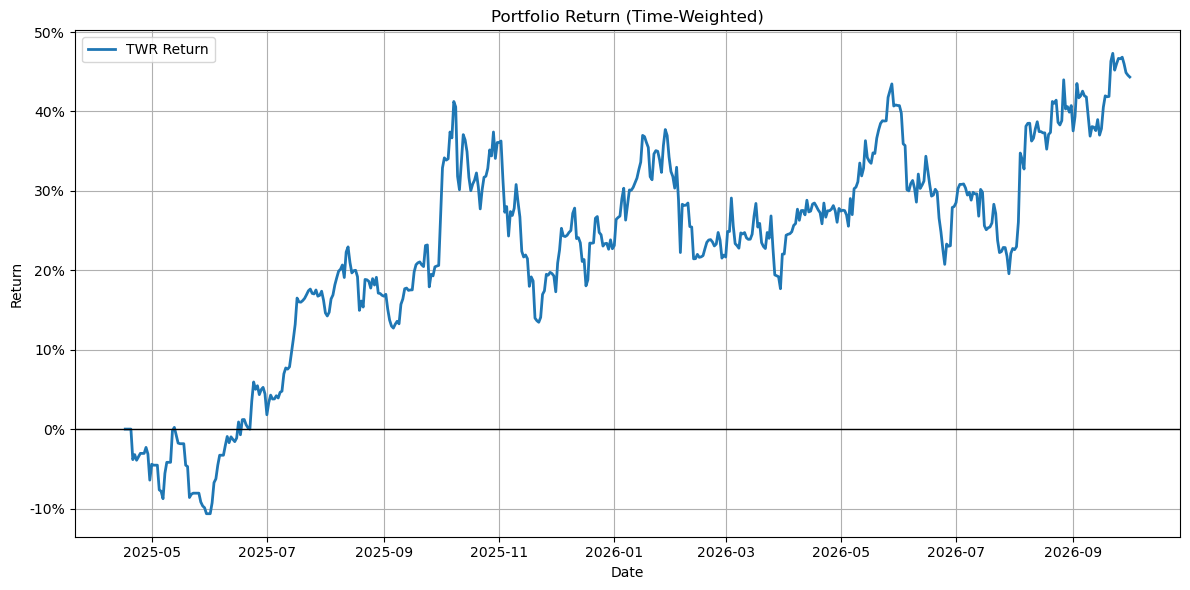

TWR: 44.33%


In [221]:
### TWR

# Daily Net CF
net_cash_flow = (
    tx.groupby("Date")["cash_flow"]
    .sum()
    .reindex(prices.index, fill_value=0)
)
# Reverse sign for TWR
net_cash_flow = -net_cash_flow

# TWR Return
portfolio_return = (
    (portfolio_value - (portfolio_value.shift(1) + net_cash_flow))
    / (portfolio_value.shift(1) + net_cash_flow)
)

# Clean numerical issues
portfolio_return = portfolio_return.replace([np.inf, -np.inf], 0).fillna(0)

# --------------------------
# Cumulative TWR
# --------------------------

cum_twr = (1 + portfolio_return).cumprod() - 1

# PLOT
plt.figure(figsize=(12,6))

plt.plot(cum_twr, label="TWR Return", linewidth=2)

plt.axhline(0, color="black", linewidth=1)

plt.title("Portfolio Return (Time-Weighted)")
plt.xlabel("Date")
plt.ylabel("Return")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"TWR: {cum_twr.iloc[-1]:.2%}")

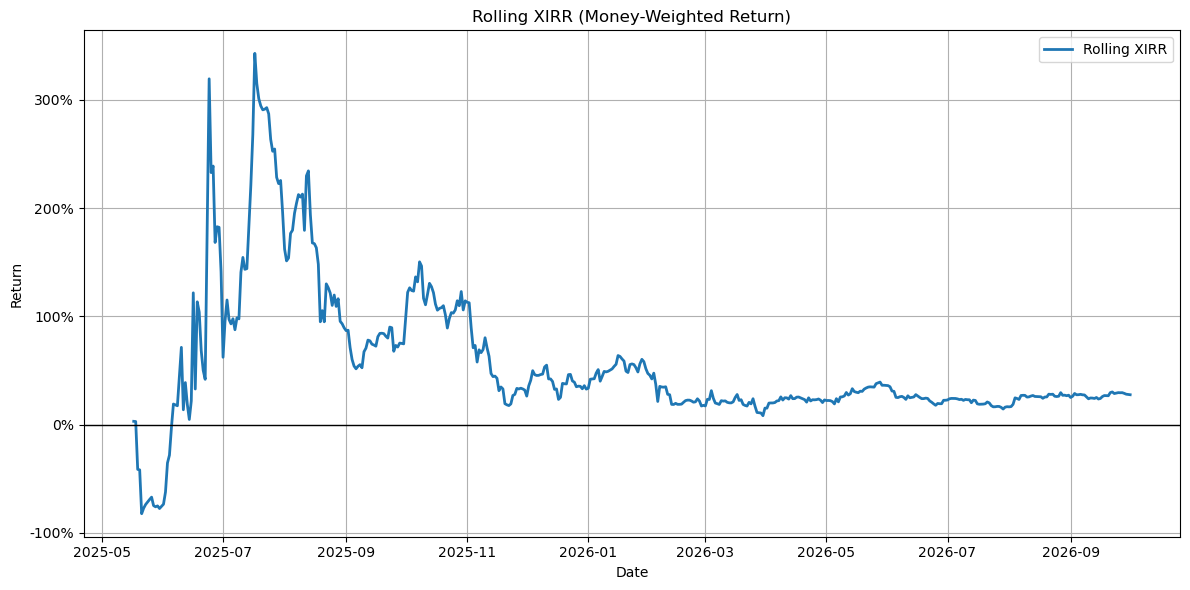

XIRR: 27.52%


In [222]:
### XIRR

# CF
cf = tx.groupby("Date")["cash_flow"].sum()

# Add final portfolio liquidation
cf = cf.copy()

# Add final liquidation value safely
final_date = portfolio_value.index[-1]
cf.loc[final_date] = cf.get(final_date, 0) + portfolio_value.iloc[-1]

cf = cf.sort_index()

# Convert dates to year
dates = cf.index
days = (dates - dates[0]).days / 365.25

# XIRR
def xirr(rate):
    return np.sum(cf.values / (1 + rate) ** days)

if (cf > 0).any() and (cf < 0).any():
    try:
        irr = brentq(xirr, -0.99, 10)
    except:
        irr = np.nan
else:
    irr = np.nan

# Over time
rolling_xirr = []

for i in range(30, len(portfolio_value)):
    
    # Build sub cash flow
    sub_cf = tx[tx["Date"] <= portfolio_value.index[i]]
    sub_cf = sub_cf.groupby("Date")["cash_flow"].sum().copy()
    
    date_i = portfolio_value.index[i]
    
    # Safe addition of portfolio value
    sub_cf.loc[date_i] = sub_cf.get(date_i, 0) + portfolio_value.iloc[i]
    
    sub_cf = sub_cf.sort_index()
    
    dates = sub_cf.index
    days = (dates - dates[0]).days / 365.25
    
    def f(rate):
        return np.sum(sub_cf.values / (1 + rate) ** days)
    
    # Ensure valid IRR inputs
    if (sub_cf > 0).any() and (sub_cf < 0).any():
        try:
            r = brentq(f, -0.99, 10)
        except:
            r = np.nan
    else:
        r = np.nan
    
    rolling_xirr.append(r)

rolling_xirr = pd.Series(
    rolling_xirr,
    index=portfolio_value.index[30:]
)

rolling_xirr = rolling_xirr.ffill()


# Plot
plt.figure(figsize=(12,6))

plt.plot(rolling_xirr, label="Rolling XIRR", linewidth=2)

plt.axhline(0, color="black", linewidth=1)

plt.title("Rolling XIRR (Money-Weighted Return)")
plt.xlabel("Date")
plt.ylabel("Return")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"XIRR: {irr:.2%}")

# PNL BY ASSET

In [223]:
# Latest and previous prices
last_prices = prices.iloc[-1]
prev_prices = prices.shift(1).iloc[-1]

# Optional: total dividend income by ticker
if "dividends_received_df" in locals():
    div_by_ticker = (
        dividends_received_df.groupby("Ticker")["Dividend_Received"]
        .sum()
    )
else:
    div_by_ticker = pd.Series(dtype=float)

# Sort transactions for inventory accounting
tx_summary = tx.sort_values(["Ticker", "Date"]).copy()

summary_records = []

for ticker, df in tx_summary.groupby("Ticker"):
    df = df.sort_values("Date")

    shares_held = 0.0
    cost_basis_open = 0.0

    realised_gain_usd = 0.0
    realised_cost_basis_sold = 0.0

    for _, row in df.iterrows():
        trade_type = row["Type"]
        qty = float(row["Shares"])
        px = float(row["Cost/Share ($)"])
        comm = float(row["Commn"]) if "Commn" in row and pd.notna(row["Commn"]) else 0.0

        if trade_type == "BUY":
            # Add shares and include buy commission in open cost basis
            shares_held += qty
            cost_basis_open += qty * px + comm

        elif trade_type == "SELL":
            if shares_held <= 0:
                continue

            avg_cost = cost_basis_open / shares_held

            # Cost basis of the sold shares
            sold_cost_basis = avg_cost * qty

            # Realised gain: proceeds - sold cost basis - sell commission
            realised_trade_gain = (qty * px) - sold_cost_basis - comm

            realised_gain_usd += realised_trade_gain
            realised_cost_basis_sold += sold_cost_basis

            # Remove sold inventory from open position
            shares_held -= qty
            cost_basis_open -= sold_cost_basis

            # Clean tiny floating point residue
            if abs(shares_held) < 1e-12:
                shares_held = 0.0
                cost_basis_open = 0.0

    # Current market data
    last_price = float(last_prices.get(ticker, 0.0))
    prev_price = float(prev_prices.get(ticker, last_price))

    market_value = shares_held * last_price
    prev_market_value = shares_held * prev_price

    # Average cost of remaining open shares
    ac_per_share = cost_basis_open / shares_held if shares_held > 0 else 0.0

    # Unrealised day gain
    day_gain_unrl_usd = shares_held * (last_price - prev_price)
    day_gain_unrl_pct = (
        day_gain_unrl_usd / prev_market_value
        if prev_market_value != 0 else 0.0
    )

    # Total unrealised gain
    tot_gain_unrl_usd = market_value - cost_basis_open
    tot_gain_unrl_pct = (
        tot_gain_unrl_usd / cost_basis_open
        if cost_basis_open != 0 else 0.0
    )

    # Realised gain %
    realised_gain_pct = (
        realised_gain_usd / realised_cost_basis_sold
        if realised_cost_basis_sold != 0 else 0.0
    )

    # Dividend income
    tot_div_income = float(div_by_ticker.get(ticker, 0.0))

    summary_records.append({
        "Ticker": ticker,
        "Shares": shares_held,
        "Last price": last_price,
        "AC/share": ac_per_share,
        "Total cost (US$)": cost_basis_open,
        "Market value (US$)": market_value,
        "Tot div income (US$)": tot_div_income,
        "Day gain UNRL (%)": day_gain_unrl_pct,
        "Day gain UNRL (US$)": day_gain_unrl_usd,
        "Tot gain UNRL (%)": tot_gain_unrl_pct,
        "Tot gain UNRL (US$)": tot_gain_unrl_usd,
        "Realised gain (%)": realised_gain_pct,
        "Realised gain (US$)": realised_gain_usd
    })

summary_df = pd.DataFrame(summary_records)

# Keep only assets currently held
summary_df = summary_df[summary_df["Shares"] > 0].copy()

# Sort by market value descending
summary_df = summary_df.sort_values("Market value (US$)", ascending=False).reset_index(drop=True)

In [224]:
# Keep raw summary_df for calculations
summary_display = summary_df.copy()

# Money columns -> 2 decimals
money_cols = [
    "Last price",
    "AC/share",
    "Total cost (US$)",
    "Market value (US$)",
    "Tot div income (US$)",
    "Day gain UNRL (US$)",
    "Tot gain UNRL (US$)",
    "Realised gain (US$)"
]

# Percentage columns -> 2 decimal places
pct_cols = [
    "Day gain UNRL (%)",
    "Tot gain UNRL (%)",
    "Realised gain (%)"
]

# Format for display
for col in money_cols:
    summary_display[col] = summary_display[col].map(lambda x: f"${x:,.2f}")

for col in pct_cols:
    summary_display[col] = summary_display[col].map(lambda x: f"{x:.2%}")

# Keep shares precise
summary_display["Shares"] = summary_display["Shares"].map(lambda x: f"{x:,.6f}")

summary_display

,Ticker,Shares,Last price,AC/share,Total cost (US$),Market value (US$),Tot div income (US$),Day gain UNRL (%),Day gain UNRL (US$),Tot gain UNRL (%),Tot gain UNRL (US$),Realised gain (%),Realised gain (US$)
0,NVDA,4.053247,$230.86,$185.96,$753.73,$935.73,$2.02,1.09%,$10.05,24.15%,$182.01,20.76%,$180.25
1,PLTR,4.146839,$190.04,$150.36,$623.52,$788.07,$0.00,1.60%,$12.40,26.39%,$164.55,22.42%,$71.43
2,ASTS,9.889525,$57.04,$73.66,$728.51,$564.10,$0.00,-3.09%,$-18.00,-22.57%,$-164.41,40.37%,$710.05
3,SOL-USD,4.225896,$118.40,$130.68,$552.23,$500.34,$0.00,0.34%,$1.70,-9.40%,$-51.89,0.00%,$0.00
4,BTC-USD,0.005359,"$84,853.10","$109,330.52",$585.90,$454.73,$0.00,1.55%,$6.96,-22.39%,$-131.17,0.00%,$0.00
5,BTI,8.303943,$53.19,$59.10,$490.73,$441.69,$28.94,-2.22%,$-10.05,-9.99%,$-49.04,12.02%,$166.61
6,KO,4.823630,$86.10,$88.11,$425.01,$415.31,$13.37,0.02%,$0.10,-2.28%,$-9.70,11.17%,$87.90
7,GOOGL,0.745557,$338.24,$353.98,$263.92,$252.18,$0.67,-1.70%,$-4.35,-4.45%,$-11.74,12.38%,$29.47
8,LYG,23.215480,$5.42,$5.85,$135.90,$125.83,$26.99,-3.73%,$-4.88,-7.41%,$-10.08,11.80%,$92.27
9,SPCX,0.621864,$148.07,$201.01,$125.00,$92.08,$0.00,-1.85%,$-1.73,-26.34%,$-32.92,0.00%,$0.00


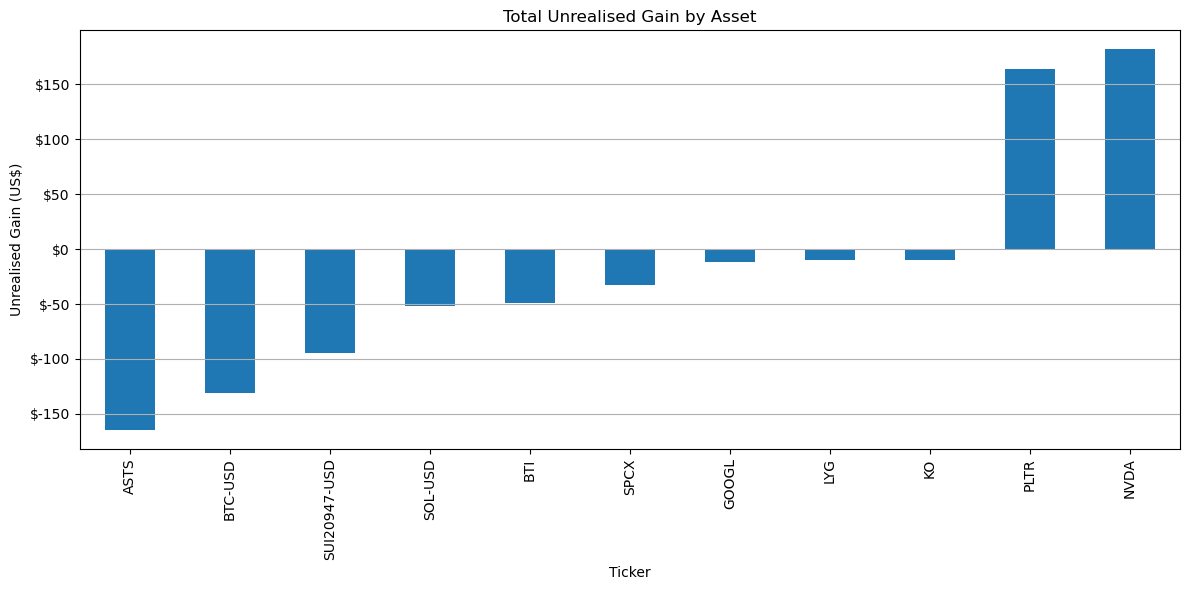

In [225]:
plt.figure(figsize=(12, 6))

summary_df.set_index("Ticker")["Tot gain UNRL (US$)"].sort_values().plot(kind="bar")

plt.title("Total Unrealised Gain by Asset")
plt.xlabel("Ticker")
plt.ylabel("Unrealised Gain (US$)")
plt.grid(True, axis="y")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()

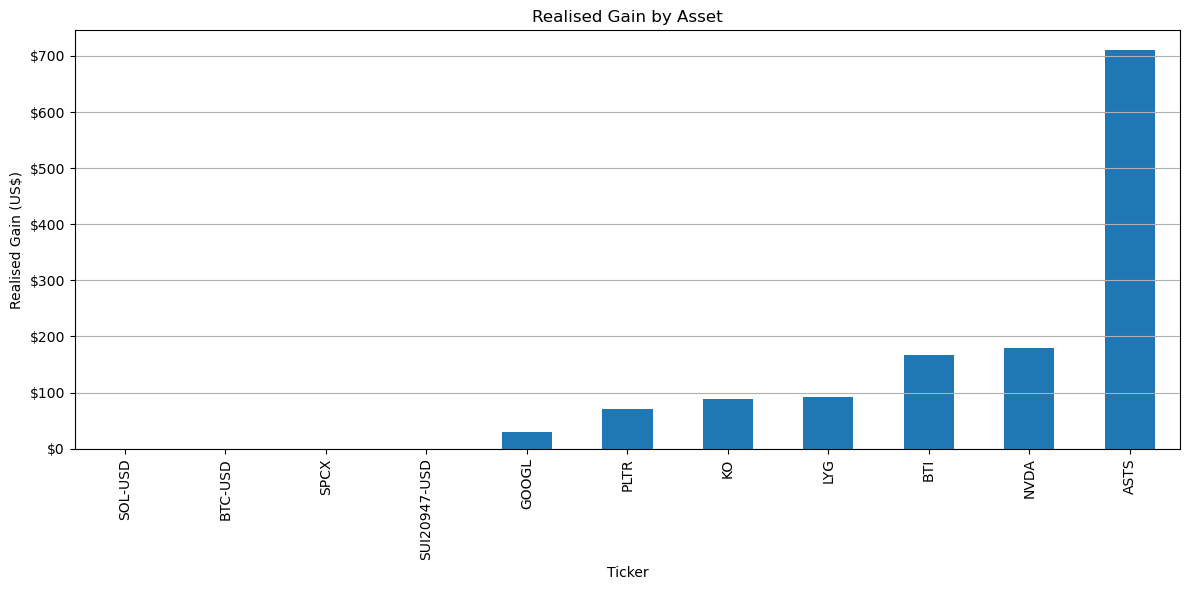

In [226]:
plt.figure(figsize=(12, 6))

summary_df.set_index("Ticker")["Realised gain (US$)"].sort_values().plot(kind="bar")

plt.title("Realised Gain by Asset")
plt.xlabel("Ticker")
plt.ylabel("Realised Gain (US$)")
plt.grid(True, axis="y")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()

In [227]:
# ============================================================
# Realised P&L per SELL order
# ============================================================
# Average-cost method, consistent with the cost-basis loop above.
# Commission handling: buy commissions are added to cost basis;
# sell commissions are netted out of proceeds.

tx_sorted = tx.sort_values(["Ticker", "Date"]).copy()

sell_pnl_records = []

for ticker, df in tx_sorted.groupby("Ticker"):
    df = df.sort_values("Date")

    shares = 0.0          # running shares held
    cost   = 0.0          # running cost basis (incl. buy commissions)

    for _, row in df.iterrows():
        qty   = float(row["Shares"])
        px    = float(row["Cost/Share ($)"])
        comm  = float(row["Commn"]) if pd.notna(row["Commn"]) else 0.0
        proceeds = float(row["Total Cost/Credit ($)"])   # net credit on the sell

        if row["Type"] == "BUY":
            shares += qty
            cost   += qty * px + comm

        elif row["Type"] == "SELL":
            if shares <= 0:
                # Sell with no recorded position — flag and skip
                sell_pnl_records.append({
                    "Date": row["Date"], "Ticker": ticker,
                    "Shares Sold": qty, "Sell Price": px,
                    "Proceeds (net)": proceeds,
                    "Avg Cost/Share": np.nan, "Cost of Shares Sold": np.nan,
                    "Realised P&L ($)": np.nan, "Return (%)": np.nan,
                    "Note": "No open position"
                })
                continue

            avg_cost      = cost / shares
            qty_sold      = min(qty, shares)          # guard against over-selling
            cost_removed  = avg_cost * qty_sold
            realised      = proceeds - cost_removed
            ret_pct       = realised / cost_removed if cost_removed else np.nan

            sell_pnl_records.append({
                "Date": row["Date"],
                "Ticker": ticker,
                "Shares Sold": qty_sold,
                "Sell Price": px,
                "Proceeds (net)": proceeds,
                "Avg Cost/Share": avg_cost,
                "Cost of Shares Sold": cost_removed,
                "Realised P&L ($)": realised,
                "Return (%)": ret_pct,
                "Note": ""
            })

            shares -= qty_sold
            cost   -= cost_removed
            if abs(shares) < 1e-12:
                shares, cost = 0.0, 0.0

sell_pnl_df = pd.DataFrame(sell_pnl_records).sort_values("Date").reset_index(drop=True)

# Readable display copy
disp = sell_pnl_df.copy()
for c in ["Sell Price", "Proceeds (net)", "Avg Cost/Share", "Cost of Shares Sold", "Realised P&L ($)"]:
    disp[c] = disp[c].map(lambda x: f"${x:,.2f}" if pd.notna(x) else "—")
disp["Shares Sold"] = disp["Shares Sold"].map(lambda x: f"{x:,.6f}")
disp["Return (%)"]  = disp["Return (%)"].map(lambda x: f"{x:.2%}" if pd.notna(x) else "—")

display(disp.tail(5))
print(f"\nTotal realised P&L across all sells: ${sell_pnl_df['Realised P&L ($)'].sum():,.2f}")

,Date,Ticker,Shares Sold,Sell Price,Proceeds (net),Avg Cost/Share,Cost of Shares Sold,Realised P&L ($),Return (%),Note
18,2026-06-15,LYG,160.000000,$5.48,$874.55,$4.89,$782.28,$92.27,11.80%,
19,2026-06-17,GOOGL,0.726624,$369.28,$267.64,$327.77,$238.16,$29.47,12.38%,
20,2026-07-14,NVDA,1.254458,$208.27,$260.60,$185.96,$233.27,$27.32,11.71%,
21,2026-07-14,KO,6.813016,$84.26,$572.61,$72.79,$495.93,$76.69,15.46%,
22,2026-07-14,FANG,1.085530,$193.56,$209.58,$150.21,$163.06,$46.52,28.53%,



Total realised P&L across all sells: $1,516.32


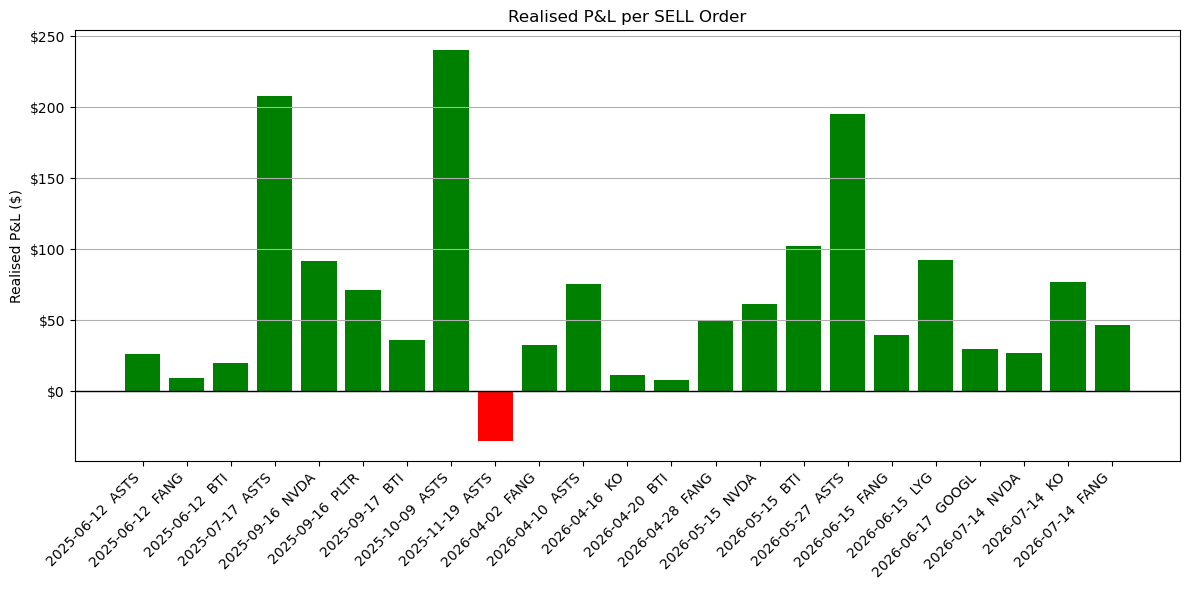

In [228]:
plt.figure(figsize=(12, 6))
labels = sell_pnl_df["Date"].dt.strftime("%Y-%m-%d") + "  " + sell_pnl_df["Ticker"]
colors = ["green" if v >= 0 else "red" for v in sell_pnl_df["Realised P&L ($)"].fillna(0)]

plt.bar(range(len(sell_pnl_df)), sell_pnl_df["Realised P&L ($)"].fillna(0), color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(range(len(sell_pnl_df)), labels, rotation=45, ha="right")
plt.title("Realised P&L per SELL Order")
plt.ylabel("Realised P&L ($)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# Dividends

In [229]:
# DIV history for each ticker
dividend_records = []

for ticker in filt_tickers:
    try:
        div_series = yf.Ticker(ticker).dividends

        if div_series.empty:
            continue

        div_df = div_series.reset_index()
        div_df.columns = ["Date", "Dividend_per_share"]
        div_df["Ticker"] = ticker

        dividend_records.append(div_df)

    except Exception as e:
        print(f"Could not download dividends for {ticker}: {e}")

# Combine all dividend histories
if dividend_records:
    dividends_df = pd.concat(dividend_records, ignore_index=True)
else:
    dividends_df = pd.DataFrame(columns=["Date", "Dividend_per_share", "Ticker"])

dividends_df["Date"] = pd.to_datetime(dividends_df["Date"])
dividends_df = dividends_df.sort_values(["Ticker", "Date"])
dividends_df["Date"] = pd.to_datetime(dividends_df["Date"]).dt.tz_localize(None).dt.normalize()
tx["Date"] = pd.to_datetime(tx["Date"]).dt.normalize()
daily_holdings.index = pd.to_datetime(daily_holdings.index).normalize()

In [230]:
# Determine the number of shares held on each div date
dividend_records_with_shares = []


for _, row in dividends_df.iterrows():
    ticker = row["Ticker"]
    div_date = row["Date"]

    # If ticker exists in daily_holdings and date exists in index
    if ticker in daily_holdings.columns and div_date in daily_holdings.index:
        shares_held = daily_holdings.loc[div_date, ticker]
    else:
        shares_held = 0

    dividend_records_with_shares.append(shares_held)

dividends_df["Shares_Held"] = dividend_records_with_shares

In [231]:
# Compute div received
# ------------------------------------------------------------
# Dividend received = dividend per share × shares held
# ------------------------------------------------------------
dividends_df["Dividend_Received"] = (
    dividends_df["Dividend_per_share"] * dividends_df["Shares_Held"]
)

# Keep only positive dividend receipts
dividends_received_df = dividends_df[dividends_df["Dividend_Received"] > 0].copy()

In [232]:
# Total Div Received
monthly_dividends = (
    dividends_received_df
    .groupby(dividends_received_df["Date"].dt.to_period("M"))["Dividend_Received"]
    .sum()
)

monthly_dividends.index = monthly_dividends.index.to_timestamp()
monthly_dividend_table = monthly_dividends.to_frame(name="Monthly_Dividend_Received")
monthly_dividend_table["Cumulative_Dividends"] = monthly_dividend_table["Monthly_Dividend_Received"].cumsum()

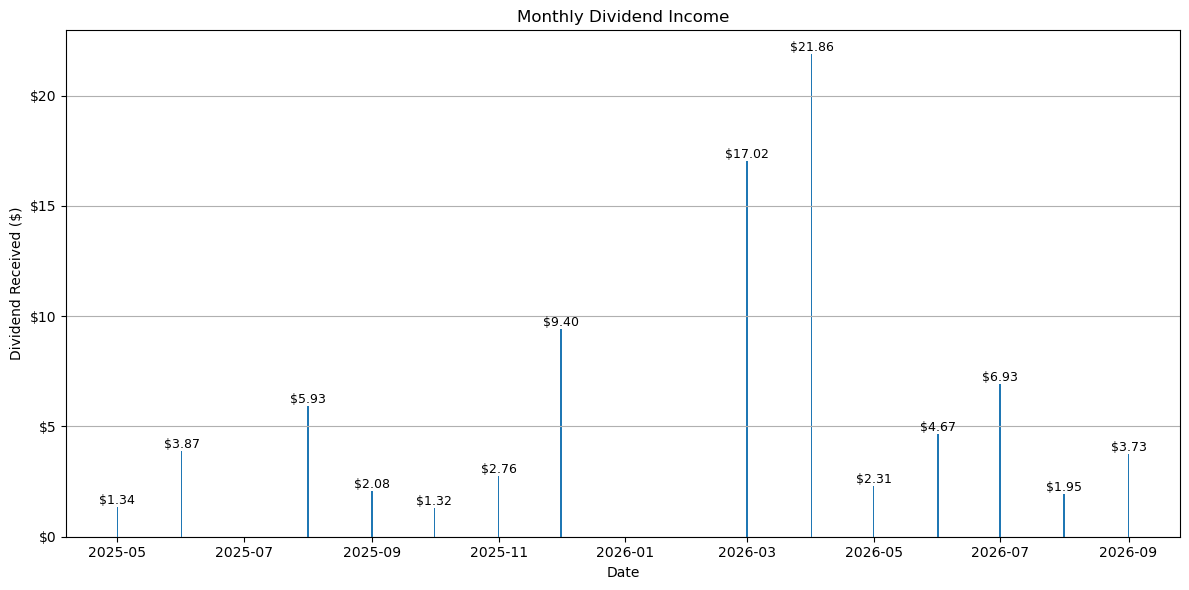

Total Dividends Received: $85.21


In [233]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_dividends.index,
    monthly_dividends.values
)

plt.title("Monthly Dividend Income")
plt.xlabel("Date")
plt.ylabel("Dividend Received ($)")
plt.grid(True, axis="y")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# Value labels
for x, y in zip(monthly_dividends.index, monthly_dividends.values):
    if y > 0:
        plt.text(
            x,
            y,
            f"${y:,.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

# Total div
total_dividends = dividends_received_df["Dividend_Received"].sum()
print(f"Total Dividends Received: ${total_dividends:,.2f}")

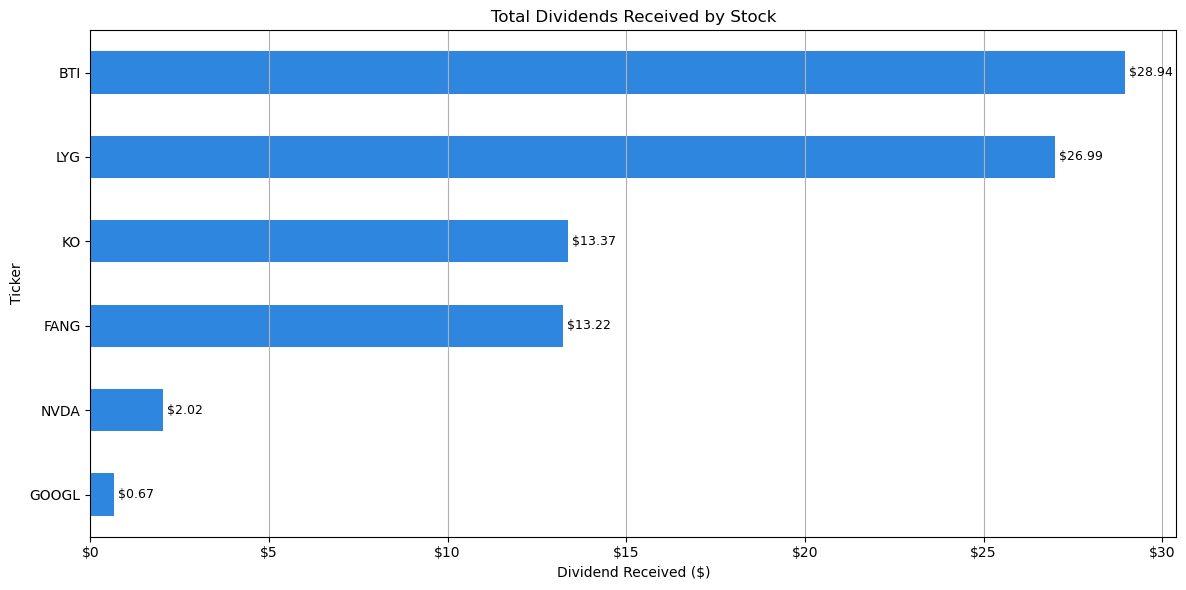

Total dividends received: $85.21


In [234]:
# Dividend received by stock (total to date)
dividends_by_ticker = (
    dividends_received_df
    .groupby("Ticker")["Dividend_Received"]
    .sum()
    .sort_values(ascending=True)        # ascending so largest sits at the top of a horizontal bar
)

plt.figure(figsize=(12, 6))
dividends_by_ticker.plot(kind="barh", color="#2e86de")

plt.title("Total Dividends Received by Stock")
plt.xlabel("Dividend Received ($)")
plt.ylabel("Ticker")
plt.grid(True, axis="x")
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# value labels at the end of each bar
for i, v in enumerate(dividends_by_ticker.values):
    plt.text(v, i, f" ${v:,.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Total dividends received: ${dividends_by_ticker.sum():,.2f}")

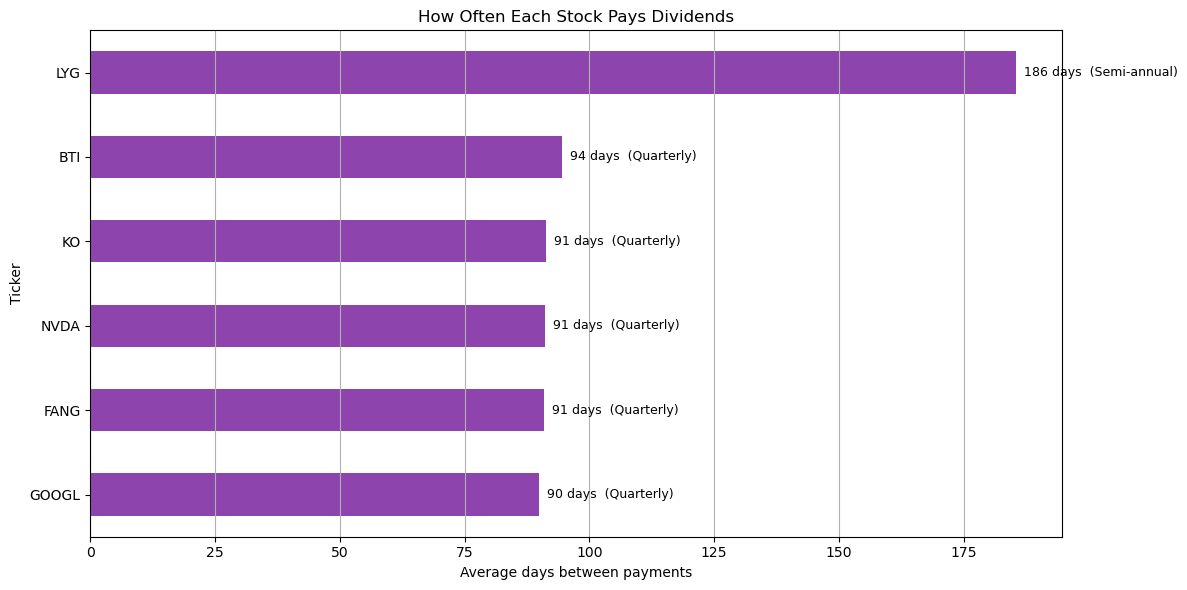

In [235]:
# How often each ticker pays a dividend (avg days between payouts)
cadence = (
    dividends_received_df
    .sort_values(["Ticker", "Date"])
    .groupby("Ticker")["Date"]
    .apply(lambda d: d.diff().dt.days.mean())
    .dropna()
    .sort_values(ascending=True)        # most frequent at the top
)

# Translate days into a human label
def cadence_label(days):
    if days < 45:    return "Monthly"
    if days < 135:   return "Quarterly"
    if days < 250:   return "Semi-annual"
    return "Annual"

plt.figure(figsize=(12, 6))
cadence.plot(kind="barh", color="#8e44ad")

plt.title("How Often Each Stock Pays Dividends")
plt.xlabel("Average days between payments")
plt.ylabel("Ticker")
plt.grid(True, axis="x")

for i, (ticker, days) in enumerate(cadence.items()):
    plt.text(days, i, f"  {days:.0f} days  ({cadence_label(days)})",
             va="center", fontsize=9)

plt.tight_layout()
plt.show()

# DASHBOARD

In [236]:
# ---------------- 1. Portfolio value over time ----------------
fig_value = go.Figure()
fig_value.add_trace(go.Scatter(x=portfolio_value.index, y=portfolio_value.values,
                               name="Portfolio Value", line=dict(width=2)))
fig_value.add_trace(go.Scatter(x=portfolio_cost_basis.index, y=portfolio_cost_basis.values,
                               name="Cost Basis", line=dict(width=2)))
fig_value.add_trace(go.Scatter(x=invested_capital.index, y=invested_capital.values,
                               name="Invested Capital", line=dict(width=2)))
fig_value.update_layout(title="Portfolio Value Over Time",
                        xaxis_title="Date", yaxis_title="USD",
                        yaxis_tickprefix="$", yaxis_tickformat=",",
                        height=450, template="plotly_white")

# ---------------- 2. Current allocation ----------------
latest_positions = position_values.iloc[-1]
latest_positions = latest_positions[latest_positions > 0]
asset_type_values = latest_positions.groupby(ticker_asset_type.loc[latest_positions.index]).sum()
latest_pct = (latest_positions / latest_positions.sum()).sort_values()

fig_alloc = make_subplots(rows=1, cols=2,
                          specs=[[{"type": "pie"}, {"type": "bar"}]],
                          subplot_titles=("By Asset Type", "By Ticker (%)"))
fig_alloc.add_trace(go.Pie(labels=asset_type_values.index,
                           values=asset_type_values.values,
                           hole=0.3), row=1, col=1)
fig_alloc.add_trace(go.Bar(y=latest_pct.index, x=latest_pct.values,
                           orientation="h",
                           text=[f"{v:.1%}" for v in latest_pct.values],
                           textposition="outside",
                           marker_color=["#ee5253" if ticker_asset_type[t] == "Equity"
                                         else "#2e86de" for t in latest_pct.index]),
                   row=1, col=2)
fig_alloc.update_xaxes(tickformat=".0%", row=1, col=2)
fig_alloc.update_layout(title="Current Allocation", height=500,
                        showlegend=False, template="plotly_white")

# ---------------- 3. P&L breakdown chart ----------------
fig_pnl = go.Figure()
fig_pnl.add_trace(go.Scatter(x=unrealised_pnl.index, y=unrealised_pnl.values,
                             name="Unrealised P&L", line=dict(width=2)))
fig_pnl.add_trace(go.Scatter(x=realised_pnl.index, y=realised_pnl.values,
                             name="Realised P&L", line=dict(width=2)))
fig_pnl.add_trace(go.Scatter(x=total_pnl.index, y=total_pnl.values,
                             name="Total P&L", line=dict(width=3)))
fig_pnl.add_hline(y=0, line_color="black", line_width=1)
fig_pnl.update_layout(title="Portfolio P&L Breakdown",
                      xaxis_title="Date", yaxis_title="USD",
                      yaxis_tickprefix="$", yaxis_tickformat=",",
                      height=450, template="plotly_white")

# ---------------- 4. P&L summary cards ----------------
current_unrealised = unrealised_pnl.iloc[-1]
current_realised   = realised_pnl.iloc[-1]
current_total      = total_pnl.iloc[-1]
current_value      = portfolio_value.iloc[-1]

def card(label, value, is_pnl=True):
    color = "#27ae60" if (is_pnl and value >= 0) else ("#c0392b" if is_pnl else "#2c3e50")
    return f"""
    <div class="card">
        <div class="card-label">{label}</div>
        <div class="card-value" style="color: {color}">${value:,.2f}</div>
    </div>"""

summary_cards = (
    card("Portfolio Value", current_value, is_pnl=False) +
    card("Total P&L", current_total) +
    card("Unrealised P&L", current_unrealised) +
    card("Realised P&L", current_realised)
)

# ---------------- 5. Per-asset holdings table ----------------
display_cols = ["Ticker", "Shares", "Last price", "AC/share",
                "Market value (US$)", "Tot gain UNRL (US$)", "Tot gain UNRL (%)",
                "Realised gain (US$)"]
table_df = summary_df[display_cols].copy()
for col in ["Last price", "AC/share", "Market value (US$)",
            "Tot gain UNRL (US$)", "Realised gain (US$)"]:
    table_df[col] = table_df[col].map(lambda x: f"${x:,.2f}")
table_df["Tot gain UNRL (%)"] = table_df["Tot gain UNRL (%)"].map(lambda x: f"{x:.2%}")
table_df["Shares"] = table_df["Shares"].map(lambda x: f"{x:,.4f}")

holdings_table = table_df.to_html(index=False, classes="holdings", border=0)

# ---------------- Assemble HTML ----------------
html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Portfolio Dashboard</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<style>
body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
       background: #f5f6fa; margin: 0; padding: 20px; color: #2c3e50; }}
h1 {{ text-align: center; margin-bottom: 10px; }}
.timestamp {{ text-align: center; color: #7f8c8d; margin-bottom: 30px; }}
.cards {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
         gap: 15px; margin-bottom: 30px; }}
.card {{ background: white; padding: 20px; border-radius: 8px;
        box-shadow: 0 2px 4px rgba(0,0,0,0.05); text-align: center; }}
.card-label {{ font-size: 0.85em; color: #7f8c8d; text-transform: uppercase; }}
.card-value {{ font-size: 1.6em; font-weight: 600; margin-top: 8px; }}
.chart {{ background: white; padding: 15px; border-radius: 8px;
         box-shadow: 0 2px 4px rgba(0,0,0,0.05); margin-bottom: 20px; }}
.holdings {{ width: 100%; border-collapse: collapse; background: white; }}
.holdings th, .holdings td {{ padding: 10px; text-align: right; border-bottom: 1px solid #ecf0f1; }}
.holdings th {{ background: #34495e; color: white; text-align: center; }}
.holdings td:first-child, .holdings th:first-child {{ text-align: left; font-weight: 600; }}
.section-title {{ font-size: 1.2em; margin: 25px 0 10px; color: #34495e; }}
</style>
</head>
<body>
<h1>Portfolio Dashboard</h1>
<div class="timestamp">Generated {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}</div>

<div class="cards">{summary_cards}</div>

<div class="chart" id="chart_value"></div>
<div class="chart" id="chart_alloc"></div>
<div class="chart" id="chart_pnl"></div>

<div class="section-title">Current Holdings</div>
<div class="chart">{holdings_table}</div>

<script>
Plotly.newPlot('chart_value', {fig_value.to_json()}.data, {fig_value.to_json()}.layout, {{responsive: true}});
Plotly.newPlot('chart_alloc', {fig_alloc.to_json()}.data, {fig_alloc.to_json()}.layout, {{responsive: true}});
Plotly.newPlot('chart_pnl', {fig_pnl.to_json()}.data, {fig_pnl.to_json()}.layout, {{responsive: true}});
</script>
</body>
</html>
"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Dashboard written to index.html")

Dashboard written to index.html
